# 02 - Preprocessing

In [1]:
import warnings
warnings.filterwarnings('ignore')


import pandas as pd
import yaml
import os
import sys
sys.path.append('..')

from src.data.dataset import masks_to_polygons_dataset,split_dataset,clear_dataset_images
from src.utils.augmentation import apply_smart_aug, suggest_n_copies
from src.data.yolo_export import convert_to_yolo_segmentation

%matplotlib inline

In [2]:
images_path = '../data/raw/images'
masks_path  = '../data/raw/masks'
stage_1_path  = '../data/processed/Stage-1'
stage_2_path  = '../data/processed/Stage-2'

hair_images_path = '../data/raw/hair_overlay'

with open(os.path.join(stage_1_path,'data.yaml')) as f:
    s1_data_yaml = yaml.safe_load(f)

with open(os.path.join(stage_2_path,'data.yaml')) as f:
    s2_data_yaml = yaml.safe_load(f)

df = pd.read_csv('../data/raw/metadata.csv')

In [3]:
nv_df = df[df['dx'] == 'nv'].sample(3000)

nv_indices = [idx for idx in range(len(df)) if df.iloc[idx]['dx'] == 'nv']

# stage 2 excludes melanoma cases, so we filter them out before extracting polygons again
mel_indices = [idx for idx in range(len(df)) if df.iloc[idx]['dx'] == 'mel']

df_stage1 = df.drop(nv_indices)
df_stage2 = df.drop(nv_indices + mel_indices)

df_stage1 = pd.concat([df_stage1,nv_df])
df_stage2 = pd.concat([df_stage2,nv_df])

df_stage1.reset_index(drop=True,inplace=True)
df_stage2.reset_index(drop=True,inplace=True)

In [4]:
df_stage1 = masks_to_polygons_dataset(masks_path, df, 'dx', stage=1, epsilon_threshold=0.01)

df_stage1['dx'] = df_stage1['class_id'].apply(lambda x: 'mel' if x[0] else 'not_mel')
df_stage1.head()

  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Suc

,lesion_id,image_id,dx,dx_type,class_id,polygons
0,HAM_0000118,ISIC_0027419,not_mel,histo,[0],"[[0.35833332, 0.09555556, 0.34833333, 0.306666..."
1,HAM_0000118,ISIC_0025030,not_mel,histo,[0],"[[0.51, 0.24222222, 0.42166665, 0.32222223, 0...."
2,HAM_0002730,ISIC_0026769,not_mel,histo,[0],"[[0.365, 0.12666667, 0.31166667, 0.19111112, 0..."
3,HAM_0002730,ISIC_0025661,not_mel,histo,[0],"[[0.47, 0.22, 0.41666666, 0.2888889, 0.4133333..."
4,HAM_0001466,ISIC_0031633,not_mel,histo,[0],"[[0.18166667, 0.13777778, 0.13833334, 0.271111..."


In [5]:
df_stage2 = masks_to_polygons_dataset(masks_path, df_stage2, 'dx', stage=2, epsilon_threshold=0.01)
df_stage2.head()

  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPolygon
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
  - Fixed Successfully!
Recovered largest part from MultiPoly

,lesion_id,image_id,dx,dx_type,class_id,polygons
0,HAM_0000118,ISIC_0027419,bkl,histo,[2],"[[0.35833332, 0.09555556, 0.34833333, 0.306666..."
1,HAM_0000118,ISIC_0025030,bkl,histo,[2],"[[0.51, 0.24222222, 0.42166665, 0.32222223, 0...."
2,HAM_0002730,ISIC_0026769,bkl,histo,[2],"[[0.365, 0.12666667, 0.31166667, 0.19111112, 0..."
3,HAM_0002730,ISIC_0025661,bkl,histo,[2],"[[0.47, 0.22, 0.41666666, 0.2888889, 0.4133333..."
4,HAM_0001466,ISIC_0031633,bkl,histo,[2],"[[0.18166667, 0.13777778, 0.13833334, 0.271111..."


In [6]:
df_stage1['dx'].value_counts()

dx
not_mel    8902
mel        1113
Name: count, dtype: int64

In [7]:
df_stage2['dx'].value_counts()

dx
nv       3000
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [8]:
s1_train_df, s1_val_df , s1_test_df = split_dataset(df_stage1, 'dx', test_size=0.2, apply_leakage_check=True)


Train Patient ID : 5976
Val Patient ID   : 747
Test Patient ID  : 747

Train Images : 8014
Val Images   : 986
Test Images  : 1015

Perfect! No Data Leakage Found.


In [9]:
s2_train_df, s2_val_df , s2_test_df = split_dataset(df_stage2, 'dx', test_size=0.2, apply_leakage_check=True)


Train Patient ID : 3320
Val Patient ID   : 415
Test Patient ID  : 415

Train Images : 4157
Val Images   : 520
Test Images  : 520

Perfect! No Data Leakage Found.


In [10]:
s1_train_df['dx'].value_counts()

dx
not_mel    7146
mel         868
Name: count, dtype: int64

In [11]:
s2_train_df['dx'].value_counts()

dx
nv       2407
bkl       886
bcc       402
akiec     258
vasc      112
df         92
Name: count, dtype: int64

In [12]:
s1_train_df.to_pickle(os.path.join(stage_1_path,'train_df_splitted.pkl'))
s1_val_df.to_pickle(os.path.join(stage_1_path,'valid_df_splitted.pkl'))
s1_test_df.to_pickle(os.path.join(stage_1_path,'test_df_splitted.pkl'))

In [13]:
s2_train_df.to_pickle(os.path.join(stage_2_path,'train_df_splitted.pkl'))
s2_val_df.to_pickle(os.path.join(stage_2_path,'valid_df_splitted.pkl'))
s2_test_df.to_pickle(os.path.join(stage_2_path,'test_df_splitted.pkl'))

In [16]:
convert_to_yolo_segmentation(images_path,stage_1_path,s1_train_df,s1_val_df,s1_test_df)

Found 736 images matching target='all'.


Deleting all images...: 100%|██████████| 736/736 [00:00<00:00, 2331.72it/s]

Deleted 736 images. Failed: 0.
Found 771 images matching target='all'.



Deleting all images...: 100%|██████████| 771/771 [00:00<00:00, 2154.69it/s]


Deleted 771 images. Failed: 0.


...

train Done!


val Is Processing Now...: 100%|██████████| 986/986 [00:02<00:00, 444.44it/s]


val Done!


test Is Processing Now...: 100%|██████████| 1015/1015 [00:02<00:00, 341.68it/s]

test Done!


In [17]:
convert_to_yolo_segmentation(images_path,stage_2_path,s2_train_df,s2_val_df,s2_test_df)

Found 396 images matching target='all'.


Deleting all images...: 100%|██████████| 396/396 [00:00<00:00, 1907.41it/s]

Deleted 396 images. Failed: 0.
Found 400 images matching target='all'.



Deleting all images...: 100%|██████████| 400/400 [00:00<00:00, 2049.25it/s]


Deleted 400 images. Failed: 0.


...

train Done!


val Is Processing Now...: 100%|██████████| 520/520 [00:01<00:00, 344.90it/s]


val Done!


test Is Processing Now...: 100%|██████████| 520/520 [00:01<00:00, 347.26it/s]

test Done!


In [24]:
DERM_AUG_CONFIG = {
    'hflip_p': 0.5,
    'vflip_p': 0.5,
    'rotate_limit': 20,
    'rotate_p': 0.5,
    'brightness_limit': 0.15,
    'contrast_limit': 0.15,
    'brightness_contrast_p': 0.4,
    'hue_shift_limit': 4,
    'sat_shift_limit': 10,
    'val_shift_limit': 4,
    'hue_sat_val_p': 0.4,
    'clahe_clip_limit': 2.0,
    'clahe_p': 0.3,
    'shift_limit': 0.05, 
    'scale_limit': 0.1,
    'shift_scale_rotate_p': 0.3,
    'hair_p': 0.3,
    'hair_overlay_path': hair_images_path
}

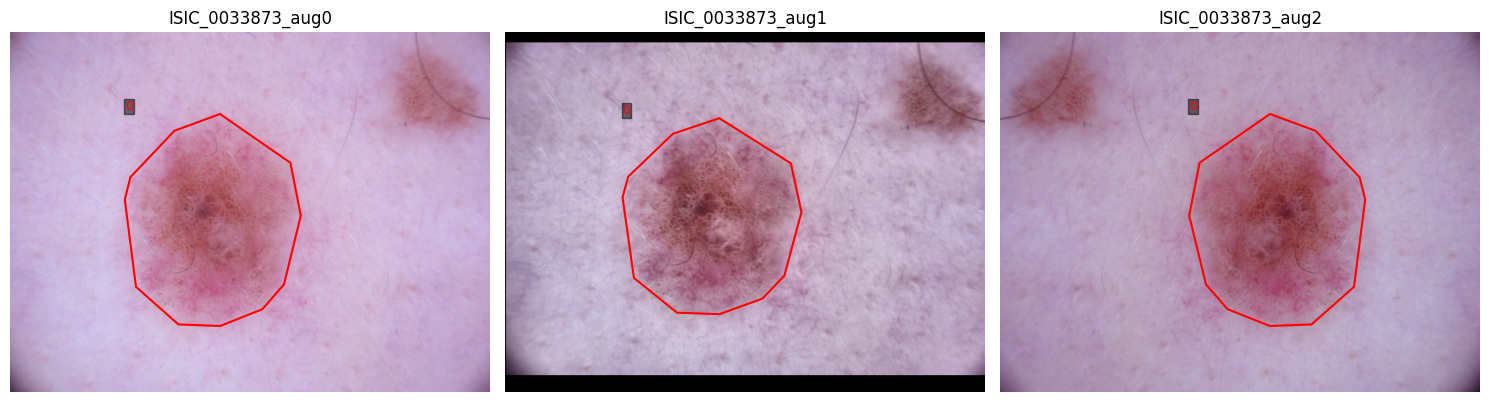

In [25]:
apply_smart_aug(s1_data_yaml,DERM_AUG_CONFIG,apply_debug=True)

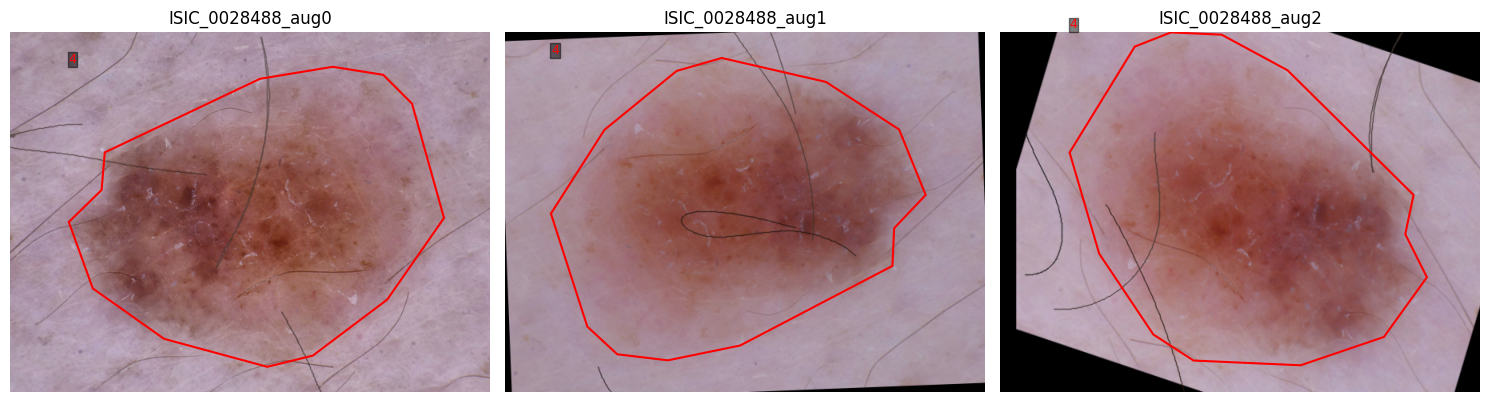

In [26]:
apply_smart_aug(s2_data_yaml,DERM_AUG_CONFIG,apply_debug=True)

In [27]:
s1_counts, s1_suggestions = suggest_n_copies(s1_data_yaml, class_names={0: 0, 1: 1})
print(s1_counts)
print(s1_suggestions)

{0: 7162, 1: 868}
{0: 0, 1: 7}


In [28]:
s2_counts, s2_suggestions = suggest_n_copies(s2_data_yaml, class_names={0: 0,
                                                                         1: 1,
                                                                           2: 2,
                                                                             3: 3,
                                                                               4: 4,
                                                                                 5: 5})
print(s2_counts)
print(s2_suggestions)

{4: 2417, 3: 92, 2: 887, 1: 402, 5: 112, 0: 259}
{4: 0, 3: 25, 2: 2, 1: 5, 5: 21, 0: 8}


In [29]:
apply_smart_aug(s1_data_yaml, DERM_AUG_CONFIG, n_copies_per_class=s1_suggestions)

Augmenting Images Now...: 100%|██████████| 8014/8014 [03:14<00:00, 41.14it/s] 


In [30]:
apply_smart_aug(s2_data_yaml,DERM_AUG_CONFIG, n_copies_per_class=s2_suggestions)

Augmenting Images Now...:   0%|          | 0/4157 [00:00<?, ?it/s]

Augmenting Images Now...: 100%|██████████| 4157/4157 [04:07<00:00, 16.83it/s]


In [31]:
s1_counts, s1_suggestions = suggest_n_copies(s1_data_yaml, class_names={0: 'Not Mel', 1: 'Mel'})
print(s1_counts)
print(s1_suggestions)

{'Not Mel': 7162, 'Mel': 6944}
{'Not Mel': 0, 'Mel': 0}


In [32]:
s2_counts, s2_suggestions = suggest_n_copies(s2_data_yaml, class_names={0: 'AKIEC', 1: 'BCC', 2: 'BKL', 3: 'DF', 4: 'NV', 5: 'VASC' })
print(s2_counts)
print(s2_suggestions)

{'NV': 2417, 'DF': 2392, 'BKL': 2661, 'BCC': 2412, 'VASC': 2464, 'AKIEC': 2331}
{'NV': 0, 'DF': 0, 'BKL': 0, 'BCC': 0, 'VASC': 0, 'AKIEC': 0}
